In [1]:
from src.dataset.coco import COCODataset
from torch.utils.data import DataLoader
import torch

import yaml

with open("config_resnet50.yaml") as f:
    cfg = yaml.safe_load(f)

In [2]:
def collate_fn(batch):

    images = []
    targets = []

    for img, target in batch:
        images.append(img)
        targets.append(target)

    max_h = max(img.shape[1] for img in images)
    max_w = max(img.shape[2] for img in images)

    padded_images = []

    for img in images:
        
        pad_h = max_h - img.shape[1]
        pad_w = max_w - img.shape[2]

        padded = torch.nn.functional.pad(
            img, (0, pad_w, 0, pad_h)
        )

        padded_images.append(padded)
    
    return torch.stack(padded_images), targets

BATCH_SIZE = cfg['TRAIN']['BATCH_SIZE']
NUM_CLASSES = cfg['MODEL']['NUM_CLASSES']

train_dataset = COCODataset(
    img_dir = cfg['DATASET']['TRAIN']['IMAGES'],
    ann_file = cfg['DATASET']['TRAIN']['ANNOTATIONS'],
    cfg_transforms=cfg['TRANSFORMS']
)

val_dataset = COCODataset(
    img_dir = cfg['DATASET']['VAL']['IMAGES'],
    ann_file = cfg['DATASET']['VAL']['ANNOTATIONS'],
    cfg_transforms=cfg['TRANSFORMS']
)

train_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn
)

val_dataloader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn
)

loading annotations into memory...
Done (t=4.28s)
creating index...
index created!
loading annotations into memory...
Done (t=0.19s)
creating index...
index created!


In [3]:
images, targets = next(iter(train_dataloader))

print(images.shape)
print(len(targets))
print(targets[0]["boxes"].shape)

torch.Size([1, 3, 704, 704])
1
torch.Size([6, 4])


In [4]:
from src.utils import draw_boxes

npimg = images[0].detach().numpy().transpose(1, 2, 0)
npimg.shape

(704, 704, 3)

In [5]:
import matplotlib.pyplot as plt

drawed_img = draw_boxes(npimg, targets[0]['boxes'], targets[0]['labels'], torch.ones_like(targets[0]['labels']))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..255.0].


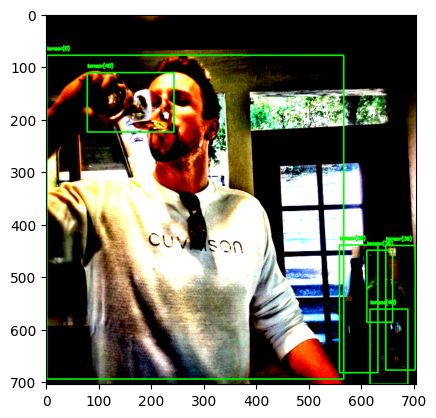

In [6]:
plt.imshow(drawed_img)

In [ ]:
from src.models.detector import Detector

seed = 1337
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)

torch.set_float32_matmul_precision('high')

device = torch.device('cuda')

model = Detector(cfg['MODEL'])

if cfg['TRAIN']['FREEZE_BACKBONE']:
    for param in model.backbone.parameters():
        param.requires_grad = False

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=cfg['TRAIN']['LR'],
    momentum=cfg['TRAIN']['MOMENTUM'],
    weight_decay=cfg['TRAIN']['WEIGHT_DECAY']
)

model.to(device)

print(f'using {device}')

using cuda


In [ ]:
from src.utils import match_anchors, encode_boxes
from src.losses import compute_losses
from tqdm import tqdm

step = 0

for epoch in range(cfg['TRAIN']['EPOCHS']):
    
    model.train()

    for images, targets in tqdm(train_dataloader):
        
        step += 1

        images = images.to(device)

        for t in targets:
            t['boxes'] = t['boxes'].to(device)
            t['labels'] = t['labels'].to(device)

        cls_outputs, box_outputs, anchors = model(images)

        batch_loss = 0

        for i in range(images.shape[0]):

            bbox = []
            logits = []

            for level in box_outputs:
                bbox.append(level[i].permute(1,2,0).reshape(-1,4))

            for level in cls_outputs:
                logits.append(level[i].permute(1,2,0).reshape(-1, NUM_CLASSES))

            bbox = torch.cat(bbox)
            logits = torch.cat(logits)

            gt_boxes = targets[i]["boxes"]
            gt_labels = targets[i]["labels"]

            losses = []

            with torch.no_grad():

                box_labels, gt_idx = match_anchors(anchors, gt_boxes)

                if gt_boxes.numel() == 0:

                    cls_labels = torch.zeros_like(box_labels)
                    box_targets = torch.zeros_like(anchors)
                
                else:
                    cls_labels = gt_labels[gt_idx]

                    box_targets = encode_boxes(
                        anchors, gt_boxes[gt_idx]
                    )
            
            cls_loss, box_loss = compute_losses(
                logits, bbox, box_labels, cls_labels, 
                box_targets, NUM_CLASSES
            )

            losses.append(cls_loss + box_loss)

        batch_loss = torch.stack(losses).mean()

        optimizer.zero_grad()

        batch_loss.backward()

        torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                10
            )

        optimizer.step()

        if step % 5000 == 0:
            model.eval()

            total_loss = 0
            num_batches = len(val_dataloader)

            with torch.no_grad():

                for images, targets in tqdm(val_dataloader):

                    images = images.to(device)

                    for t in targets:
                        t["boxes"] = t["boxes"].to(device)
                        t["labels"] = t["labels"].to(device)

                    cls_outputs, box_outputs, anchors = model(images)

                    batch_loss = torch.tensor(0.0, device=device)

                    for i in range(images.shape[0]):
                        bbox = []
                        logits = []

                        for level in box_outputs:
                            bbox.append(level[i].permute(1,2,0).reshape(-1,4))

                        for level in cls_outputs:
                            logits.append(level[i].permute(1,2,0).reshape(-1, NUM_CLASSES))

                        bbox = torch.cat(bbox)
                        logits = torch.cat(logits)

                        gt_boxes = targets[i]["boxes"]
                        gt_labels = targets[i]["labels"]

                        box_labels, gt_idx = match_anchors(
                            anchors,
                            gt_boxes
                        )
                        if gt_boxes.numel() == 0:
                        
                            cls_labels = torch.zeros_like(box_labels)
                            box_targets = torch.zeros_like(anchors)

                        else:
                            cls_labels = gt_labels[gt_idx]

                            box_targets = encode_boxes(
                                anchors,
                                gt_boxes[gt_idx]
                            )

                        cls_loss, box_loss = compute_losses(
                            logits,
                            bbox,
                            box_labels,
                            cls_labels,
                            box_targets,
                            NUM_CLASSES
                        )

                        batch_loss += cls_loss + box_loss

                    batch_loss /= BATCH_SIZE

                    total_loss += batch_loss.item()
                
            print(f'STEP: {step}, LOSS: {total_loss / num_batches}')

            model.train()


  0%|          | 0/118287 [00:00<?, ?it/s]/home/antonio-fernandes/projects/object_detector/env/lib/python3.13/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
W0317 11:43:48.828000 340055 torch/_inductor/utils.py:1679] [0/0] Not enough SMs to use max_autotune_gemm mode
  0%|          | 1/118287 [00:11<364:41:34, 11.10s/it]W0317 11:44:07.140000 340055 torch/utils/_sympy/interp.py:179] [0/1] failed while executing pow_by_natural([VR[33, int_oo], VR[-1, -1]])
W0317 11:44:07.142000 340055 torch/utils/_sympy/interp.py:179] [0/1] failed while executing pow_by_natural([VR[33, int_oo], VR[-1, -1]])
W0317 11:44:07.144000 340055 torch/utils/_sympy/interp.py:179] [0/1] failed while executing pow_by_natural([VR[33, int_oo], VR[-1, -1]])
W0317 11:44:07.145000 